# Clases difíciles: las cinco de peor AP, a ojo

AP@0,3 por clase de `yolo26s_v3` sobre test, junto a cuántas cajas tiene cada clase en train y en
test y cuán dispersas son las de train (duración y banda: mediana [p25–p75]). Quedan fuera las
clases *de ventana*, cuya caja ocupa el clip entero y no se evalúan como detección.

Para cada una de las cinco peores, 16 ventanas de train con una anotación de la clase, para ver
si las cajas son consistentes entre sí (qué se marca como una llamada, cuánto abarca, en qué
banda) o si simplemente hay pocas. En verde la clase; en gris las demás anotaciones de la ventana.

Lee el volcado de test de `runs/yolo26s_v3/` y el caché de train (`data/processed/`).

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src").is_dir())
sys.path.insert(0, str(ROOT / "src"))

from analysis.figures import draw_window, jpeg_figures, panel_grid
from analysis.predictions import load_dump
from analysis.windows import Split
from core.config import SEED, P
from data import cache
from evaluation.metrics import average_precision_per_class, window_classes
from utils.audio import y_to_hz

RUN = "yolo26s_v3"
N_WORST, N_EXAMPLES = 5, 16
jpeg_figures()
pd.set_option("display.width", 160)

## AP por clase y cuántas cajas hay

In [2]:
train = Split(cache.TRAIN)
test = load_dump(RUN, cache.TEST, train.names)
ap = average_precision_per_class(test.predictions, test.truth, len(train.names))
saturated = window_classes(test.truth, len(train.names))


def spread(values: np.ndarray, digits: int = 2) -> str:
    p25, p50, p75 = np.percentile(values, [25, 50, 75])
    return f"{p50:.{digits}f} [{p25:.{digits}f}–{p75:.{digits}f}]"


rows = []
for class_id, name in enumerate(train.names):
    of_class = train.boxes_of(class_id)
    cy, h = of_class[:, 1].numpy(), of_class[:, 3].numpy()
    rows.append(
        {
            "clase": name,
            "AP@0.3": np.nan if ap[class_id] is None else round(ap[class_id], 3),
            "cajas test": int((test.truth.labels == class_id).sum()),
            "cajas train": len(of_class),
            "duración s": spread(of_class[:, 2].numpy() * P.clip_len_s),
            "banda kHz": spread((y_to_hz(cy + h / 2, P) - y_to_hz(cy - h / 2, P)) / 1000, 1),
            "de ventana": class_id in saturated,
        }
    )
per_class = pd.DataFrame(rows).sort_values("AP@0.3").reset_index(drop=True)
worst = per_class[~per_class["de ventana"]].head(N_WORST)
per_class

,clase,AP@0.3,cajas test,cajas train,duración s,banda kHz,de ventana
0,sm/sc,0.282,56,195,0.53 [0.28–0.76],6.8 [5.8–7.6],False
1,ac/gc,0.397,56,191,1.20 [0.65–2.25],1.4 [1.0–1.7],False
2,ac/sc,0.402,54,188,1.01 [0.79–1.27],8.3 [5.6–9.3],False
3,sb/sc,0.442,37,126,0.38 [0.30–0.51],11.9 [10.2–15.1],False
4,sm/pc,0.466,83,283,0.50 [0.38–0.78],1.5 [1.2–1.9],False
5,sb/ppc,0.525,464,1340,0.20 [0.14–0.30],3.7 [2.6–4.8],False
6,sm/fs,0.528,232,799,0.19 [0.15–0.26],1.7 [0.6–2.0],False
7,sm/hic,0.551,86,296,0.25 [0.17–0.35],4.9 [4.2–11.9],False
8,lw/trino,0.573,216,739,0.49 [0.32–0.68],5.5 [4.5–6.5],False
9,sb/spc,0.601,250,859,0.15 [0.12–0.20],15.5 [13.3–17.7],False


## Las cinco peores, en ventanas de train

Ventanas al azar con una anotación entera de la clase, de grabaciones distintas mientras alcancen.

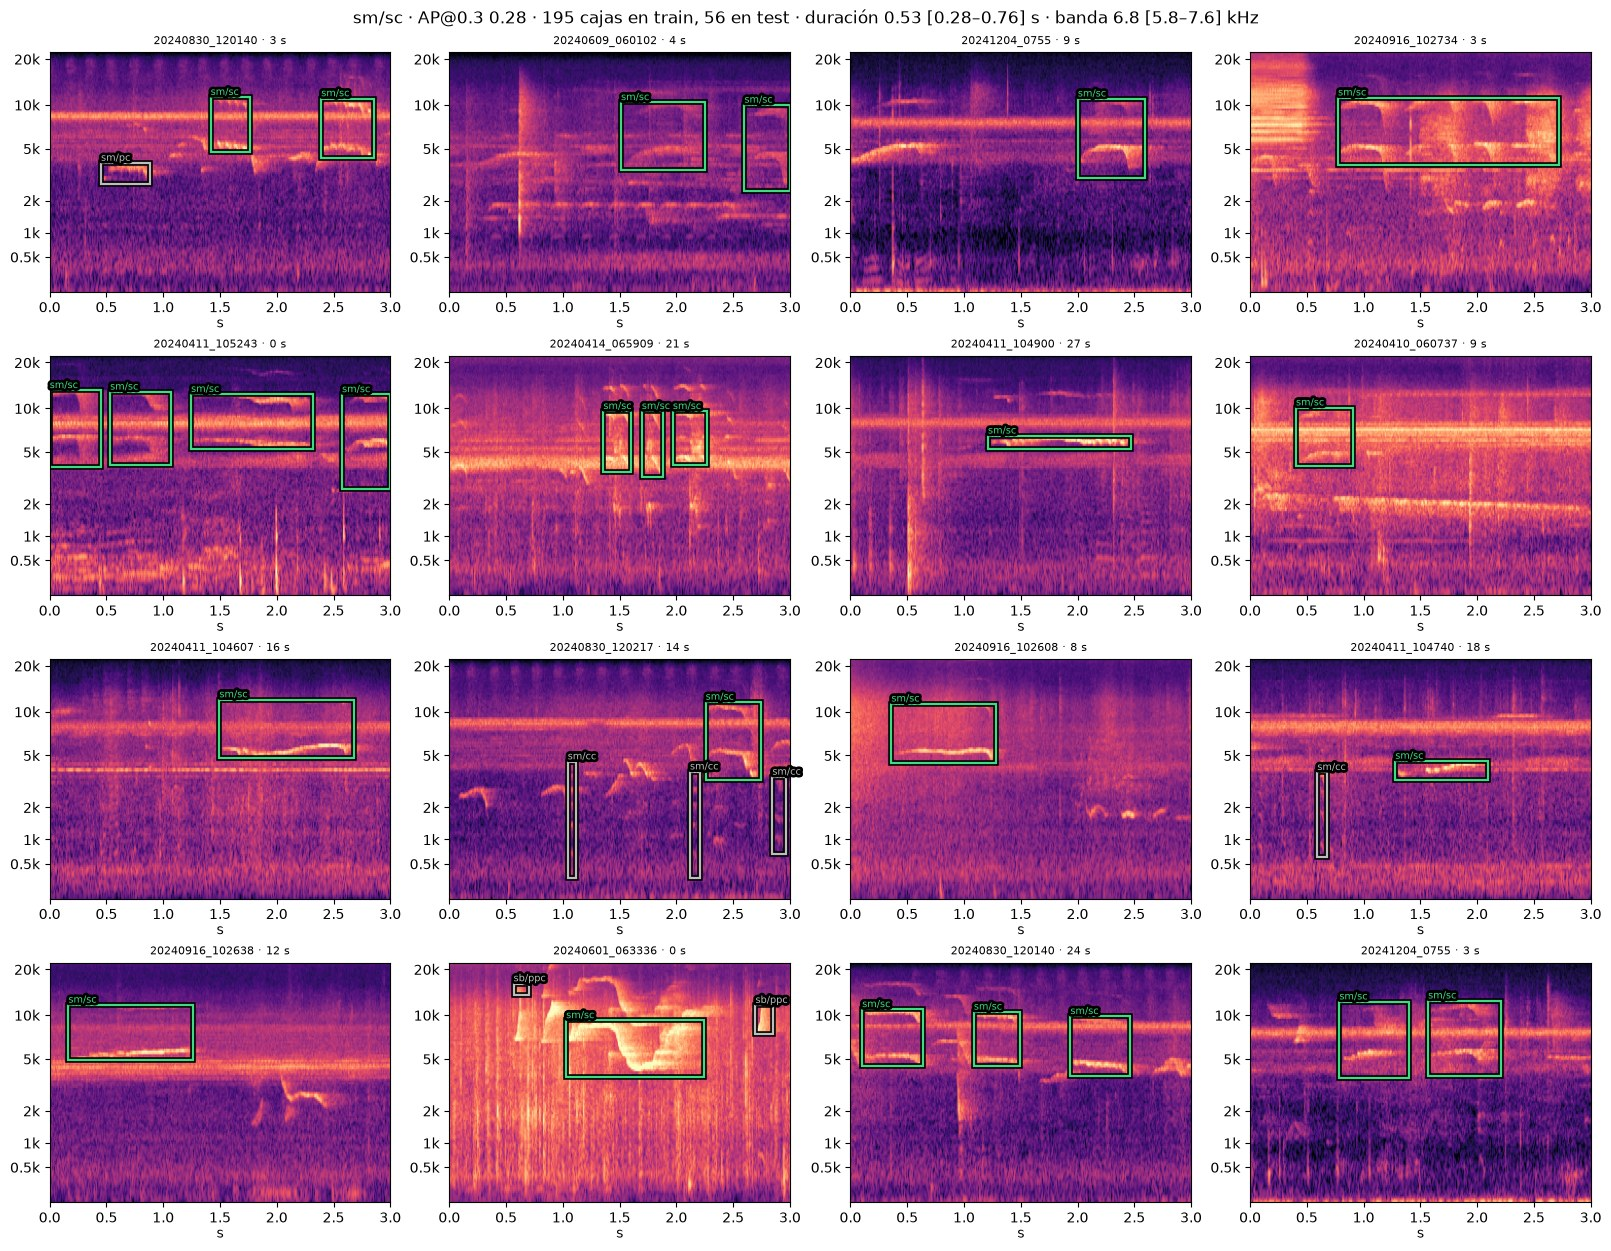

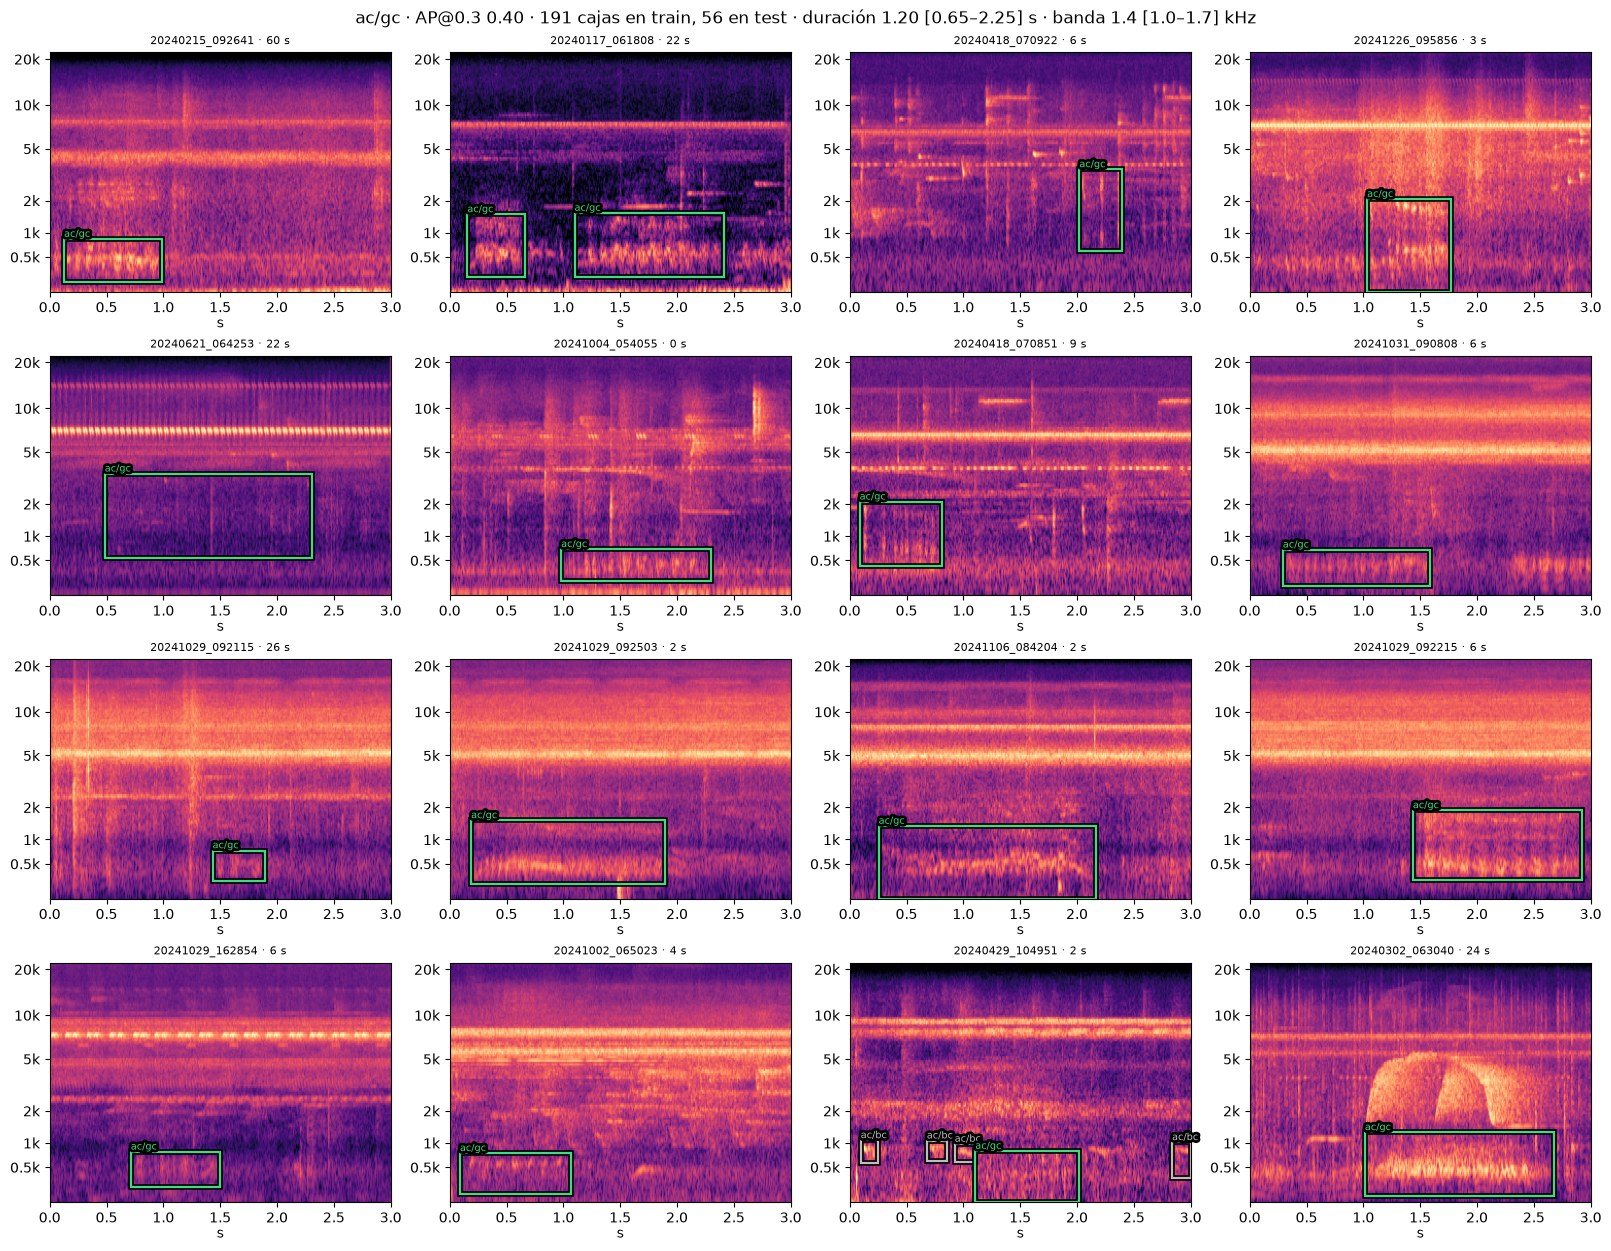

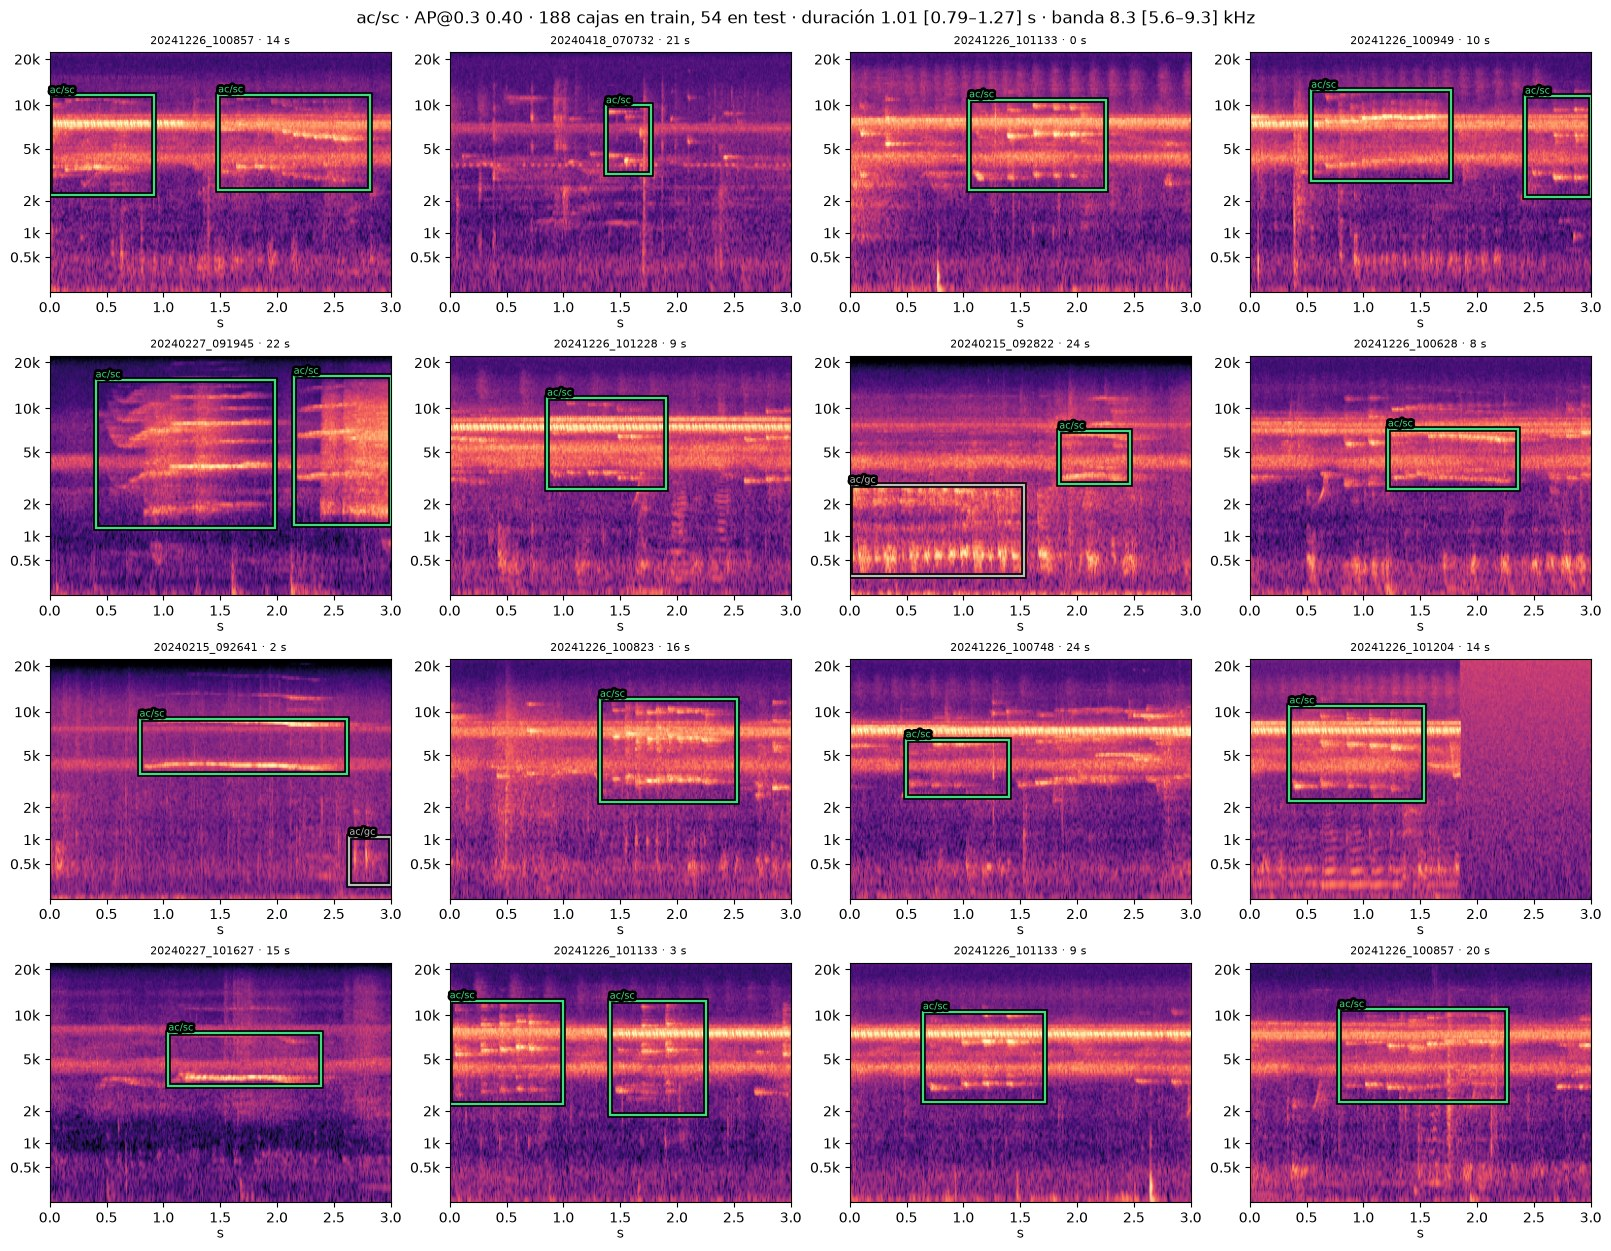

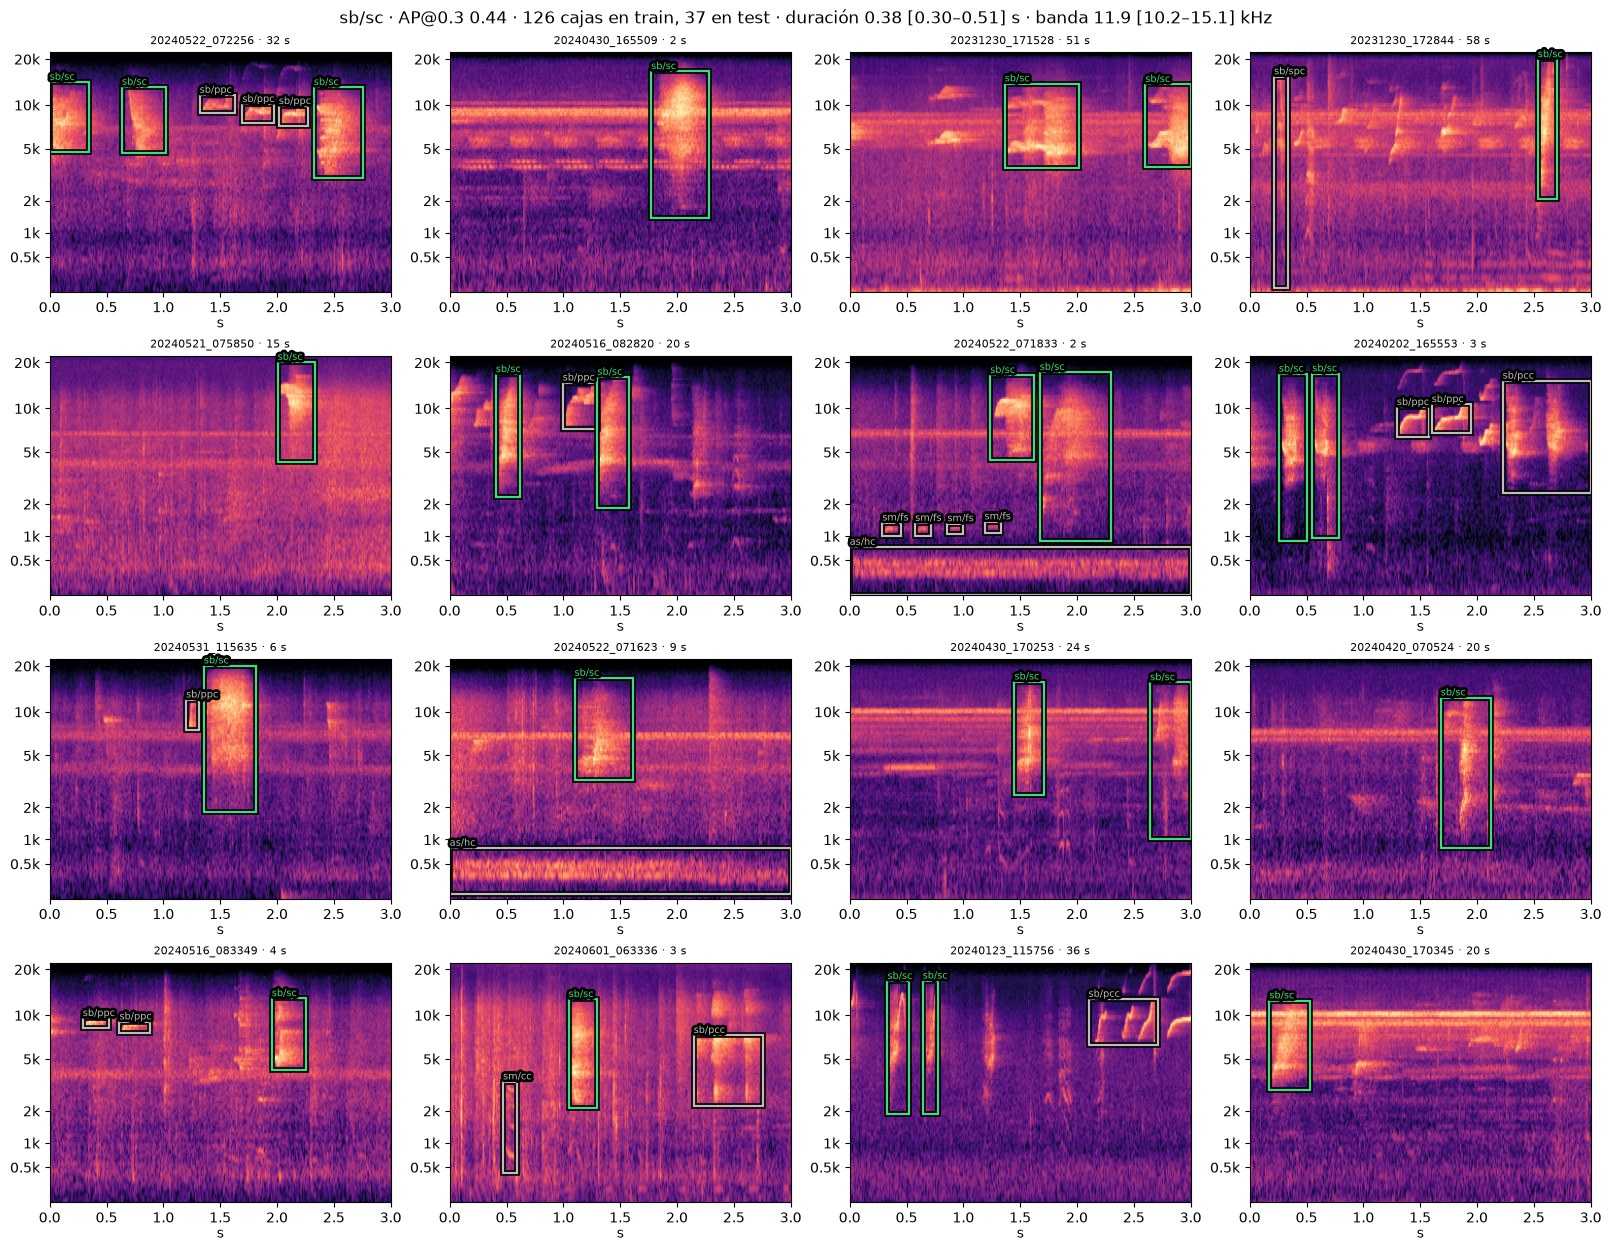

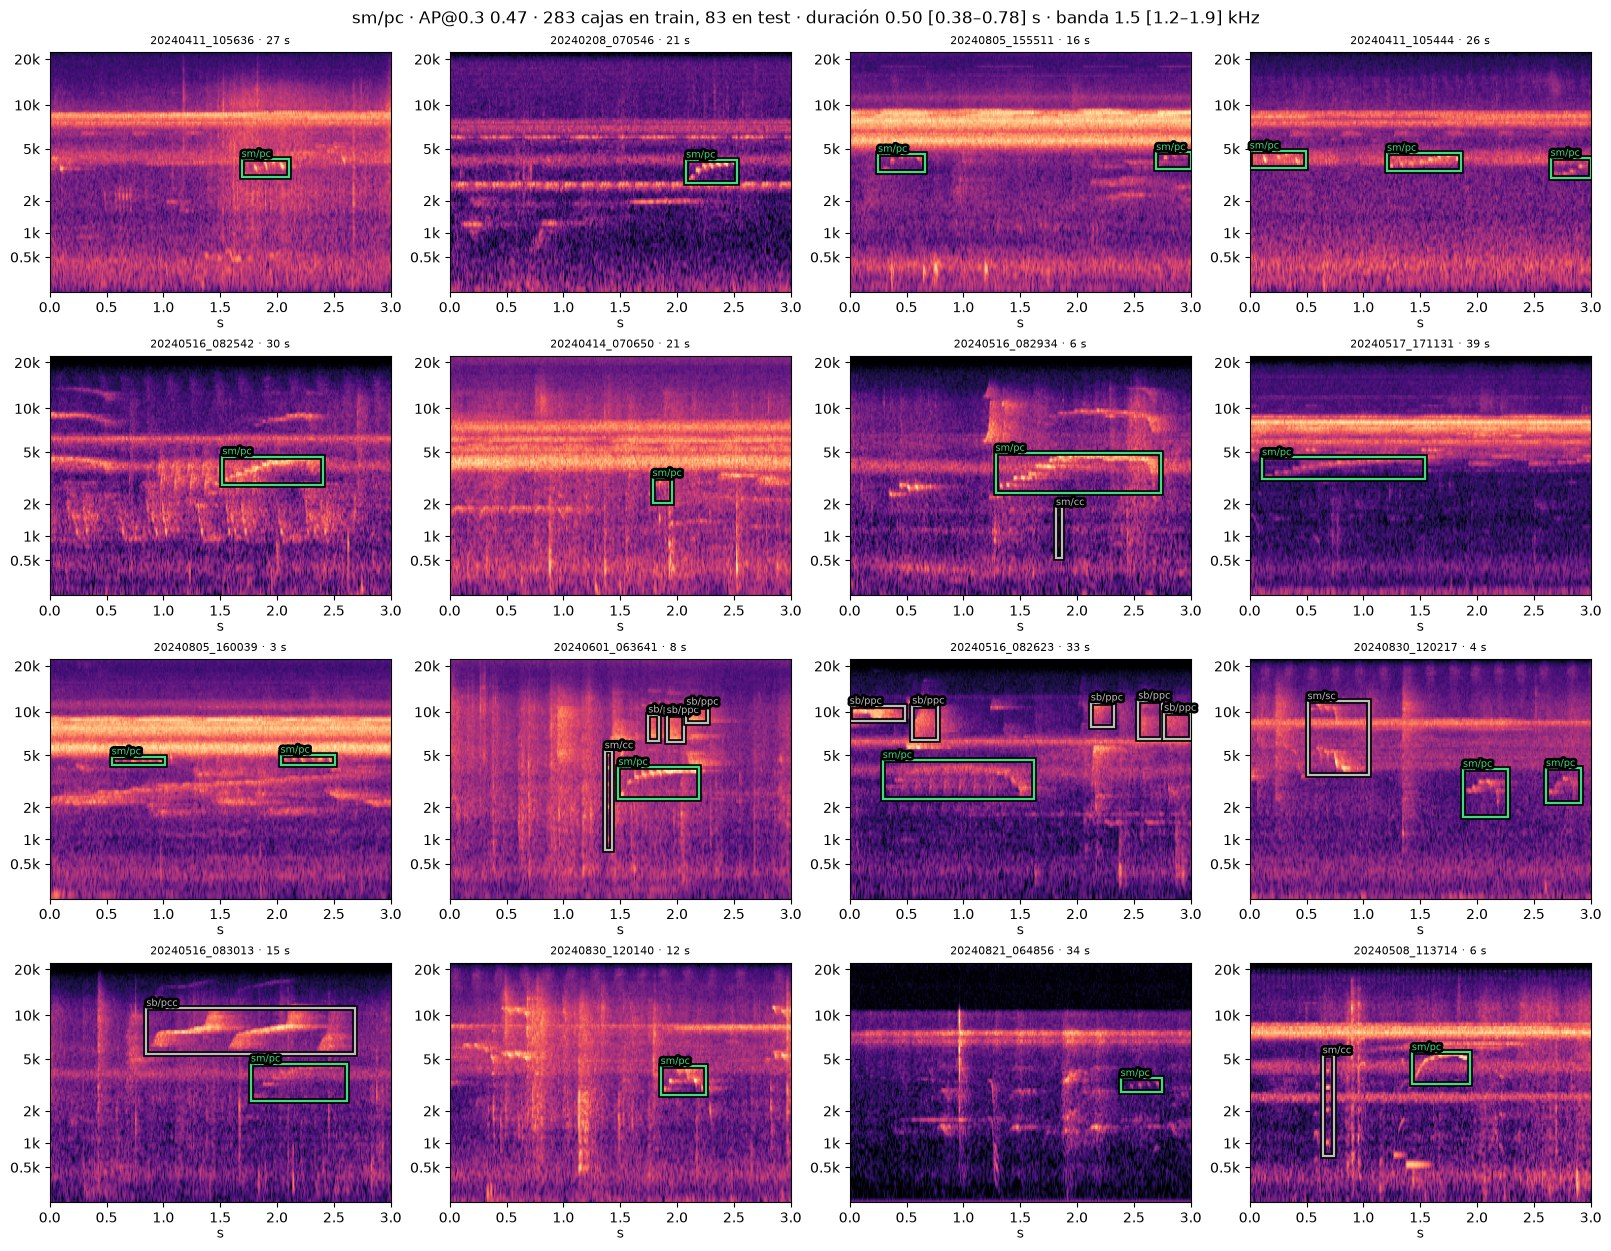

In [3]:
for row in worst.to_dict("records"):
    class_id = train.label_set.id(str(row["clase"]))
    fig, axes = panel_grid(4, 4)
    for ax, image_id in zip(axes.flat, train.examples(class_id, N_EXAMPLES, SEED + class_id)):
        draw_window(ax, train, image_id, class_id)
    fig.suptitle(
        f"{row['clase']} · AP@0.3 {row['AP@0.3']:.2f} · {row['cajas train']} cajas en train, "
        f"{row['cajas test']} en test · duración {row['duración s']} s · banda {row['banda kHz']} kHz",
        fontsize=12,
    )
    plt.show()